In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import gaussian_kde, entropy
from sklearn.ensemble import RandomForestClassifier
from sklearn.base import clone  # Added missing import
import shap
from tqdm import tqdm


In [2]:
import sys
sys.path.append("../")

In [3]:
import pandas as pd
df = pd.read_csv("../datasets/parkinsons.csv")

df.head()

df.drop("name", axis =1, inplace = True)

In [4]:
df.shape

(195, 23)

In [5]:
df.describe()

,MDVP:Fo(Hz),MDVP:Fhi(Hz),MDVP:Flo(Hz),MDVP:Jitter(%),MDVP:Jitter(Abs),MDVP:RAP,MDVP:PPQ,Jitter:DDP,MDVP:Shimmer,MDVP:Shimmer(dB),...,Shimmer:DDA,NHR,HNR,status,RPDE,DFA,spread1,spread2,D2,PPE
count,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,...,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000
mean,154.228641,197.104918,116.324631,0.006220,0.000044,0.003306,0.003446,0.009920,0.029709,0.282251,...,0.046993,0.024847,21.885974,0.753846,0.498536,0.718099,-5.684397,0.226510,2.381826,0.206552
std,41.390065,91.491548,43.521413,0.004848,0.000035,0.002968,0.002759,0.008903,0.018857,0.194877,...,0.030459,0.040418,4.425764,0.431878,0.103942,0.055336,1.090208,0.083406,0.382799,0.090119
min,88.333000,102.145000,65.476000,0.001680,0.000007,0.000680,0.000920,0.002040,0.009540,0.085000,...,0.013640,0.000650,8.441000,0.000000,0.256570,0.574282,-7.964984,0.006274,1.423287,0.044539
25%,117.572000,134.862500,84.291000,0.003460,0.000020,0.001660,0.001860,0.004985,0.016505,0.148500,...,0.024735,0.005925,19.198000,1.000000,0.421306,0.674758,-6.450096,0.174351,2.099125,0.137451
50%,148.790000,175.829000,104.315000,0.004940,0.000030,0.002500,0.002690,0.007490,0.022970,0.221000,...,0.038360,0.011660,22.085000,1.000000,0.495954,0.722254,-5.720868,0.218885,2.361532,0.194052
75%,182.769000,224.205500,140.018500,0.007365,0.000060,0.003835,0.003955,0.011505,0.037885,0.350000,...,0.060795,0.025640,25.075500,1.000000,0.587562,0.761881,-5.046192,0.279234,2.636456,0.252980
max,260.105000,592.030000,239.170000,0.033160,0.000260,0.021440,0.019580,0.064330,0.119080,1.302000,...,0.169420,0.314820,33.047000,1.000000,0.685151,0.825288,-2.434031,0.450493,3.671155,0.527367


In [6]:
df.status.unique()

array([1, 0])

In [7]:
# Load dataset and train model

X = df.drop("status", axis = 1)
y = df["status"]
feature_names = X.columns
print(feature_names)

Index(['MDVP:Fo(Hz)', 'MDVP:Fhi(Hz)', 'MDVP:Flo(Hz)', 'MDVP:Jitter(%)',
       'MDVP:Jitter(Abs)', 'MDVP:RAP', 'MDVP:PPQ', 'Jitter:DDP',
       'MDVP:Shimmer', 'MDVP:Shimmer(dB)', 'Shimmer:APQ3', 'Shimmer:APQ5',
       'MDVP:APQ', 'Shimmer:DDA', 'NHR', 'HNR', 'RPDE', 'DFA', 'spread1',
       'spread2', 'D2', 'PPE'],
      dtype='object')


In [8]:
from UQEnTree import ExplainerClassification

In [9]:
from imblearn.combine import SMOTETomek
smt = SMOTETomek(sampling_strategy=1.0)
X_resample, y_resample = smt.fit_resample(X,y)

In [10]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X_resample,y_resample, test_size=0.1, random_state=42)

In [11]:
X_resample.shape

(290, 22)

In [12]:

model = RandomForestClassifier(n_estimators=300, random_state=42)
model.fit(X_train, y_train)

RandomForestClassifier(n_estimators=300, random_state=42)

In [13]:
from sklearn.metrics import f1_score, confusion_matrix
y_pred = model.predict(X_test)
print(f1_score(y_pred, y_test))

1.0


In [14]:
y_train.value_counts()

status
1    131
0    130
Name: count, dtype: int64

In [15]:
confusion_matrix(y_test, y_pred)

array([[15,  0],
       [ 0, 14]])

In [16]:
feature_names = X_train.columns
class_names = ["No", "Yes"]

/Users/DubeyA-Dev/miniconda3/envs/taylor/lib/python3.10/site-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but DecisionTreeClassifier was fitted without feature names
  warnings.warn(
/Users/DubeyA-Dev/miniconda3/envs/taylor/lib/python3.10/site-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but DecisionTreeClassifier was fitted without feature names
  warnings.warn(
/Users/DubeyA-Dev/miniconda3/envs/taylor/lib/python3.10/site-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but DecisionTreeClassifier was fitted without feature names
  warnings.warn(
/Users/DubeyA-Dev/miniconda3/envs/taylor/lib/python3.10/site-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but DecisionTreeClassifier was fitted without feature names
  warnings.warn(
/Users/DubeyA-Dev/miniconda3/envs/taylor/lib/python3.10/site-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, bu


Explaining for class: No


Sampling hypothesis space: 100%|██████████| 500/500 [00:04<00:00, 123.36it/s]


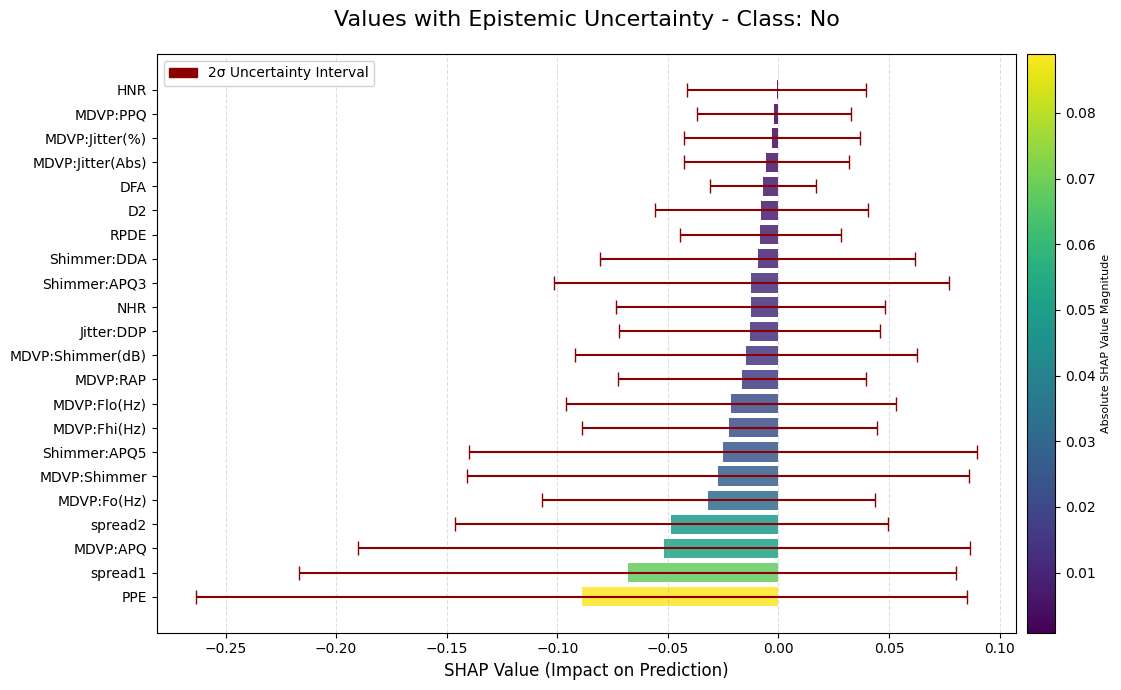

Top 5 indices: [ 0 19 12 18 21]


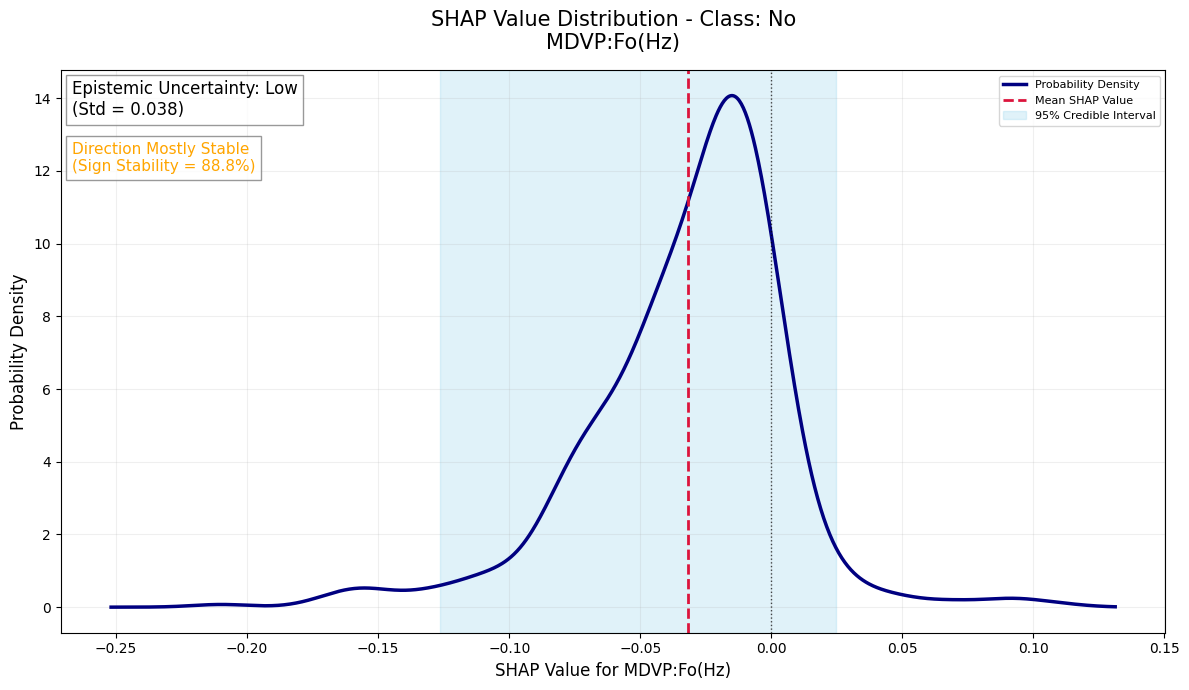

Top 5 indices: [ 0 19 12 18 21]


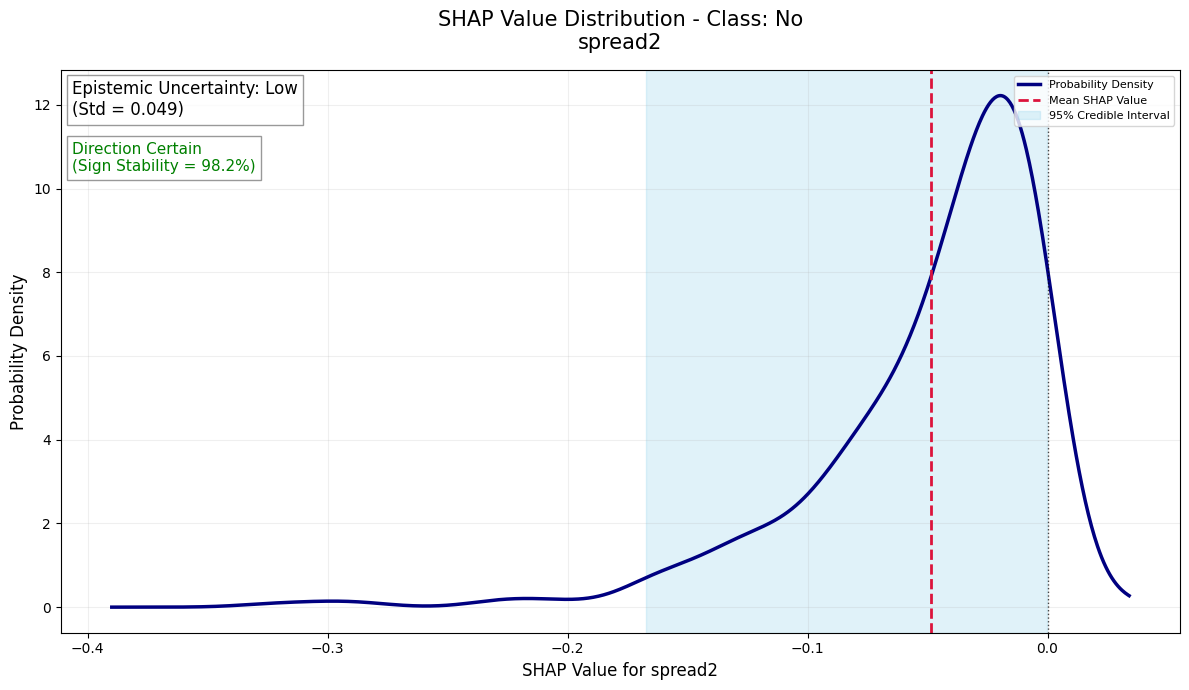

Top 5 indices: [ 0 19 12 18 21]


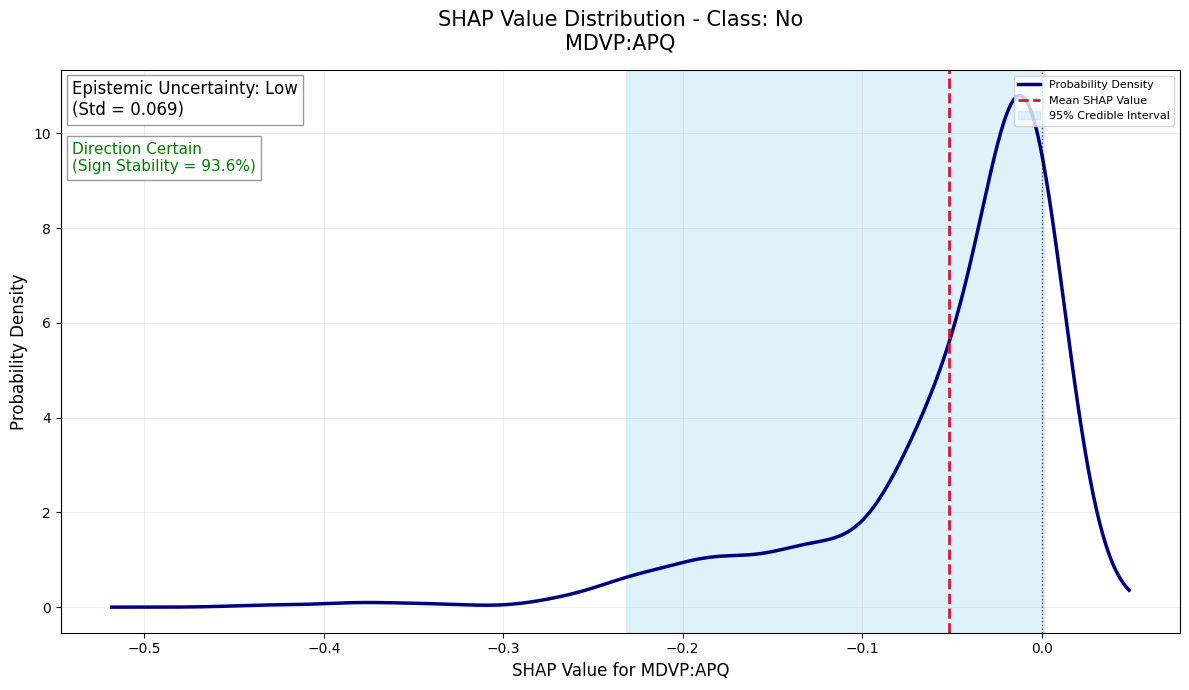

Top 5 indices: [ 0 19 12 18 21]


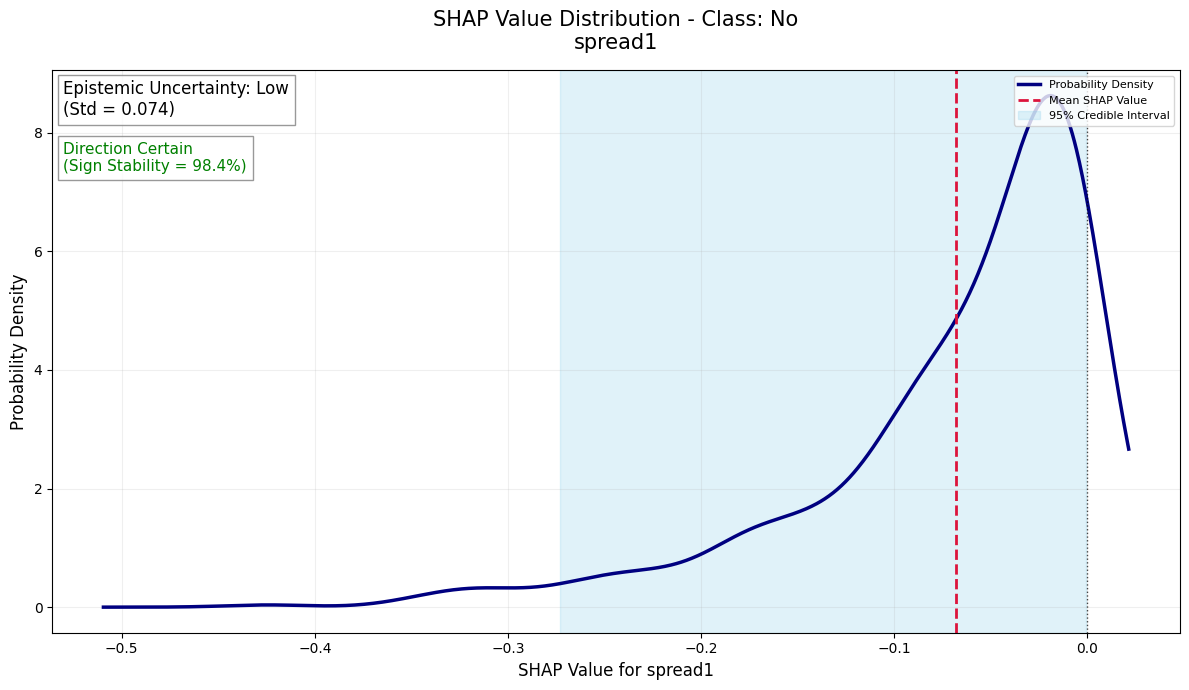

Top 5 indices: [ 0 19 12 18 21]


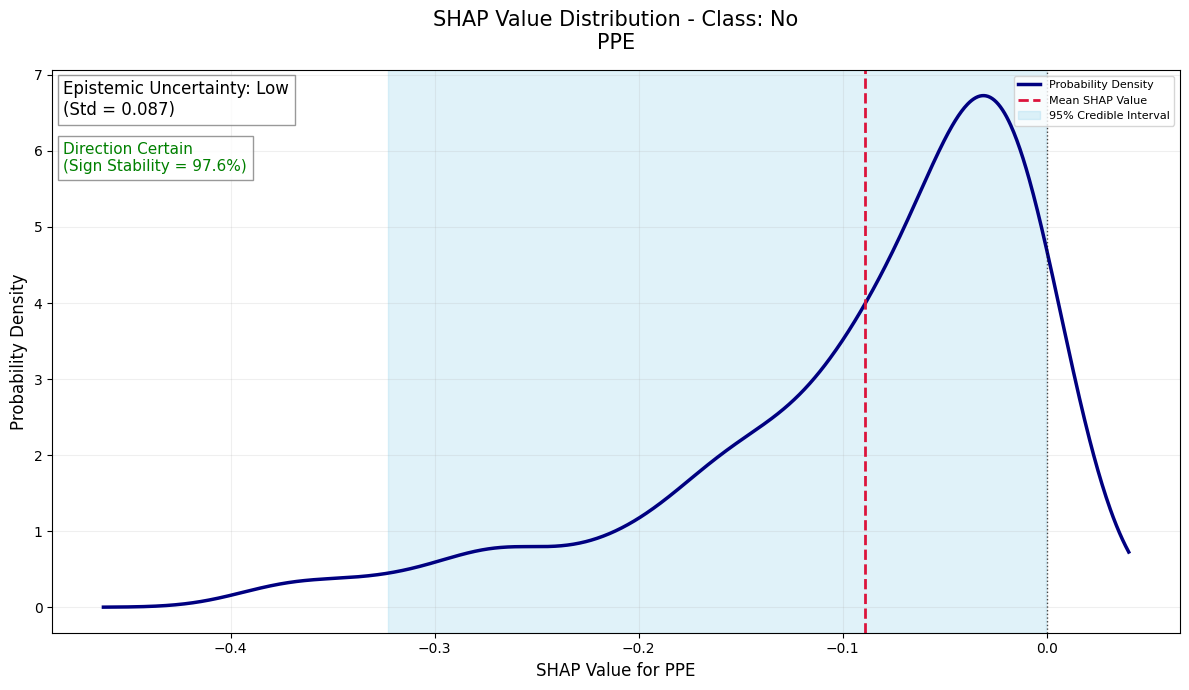

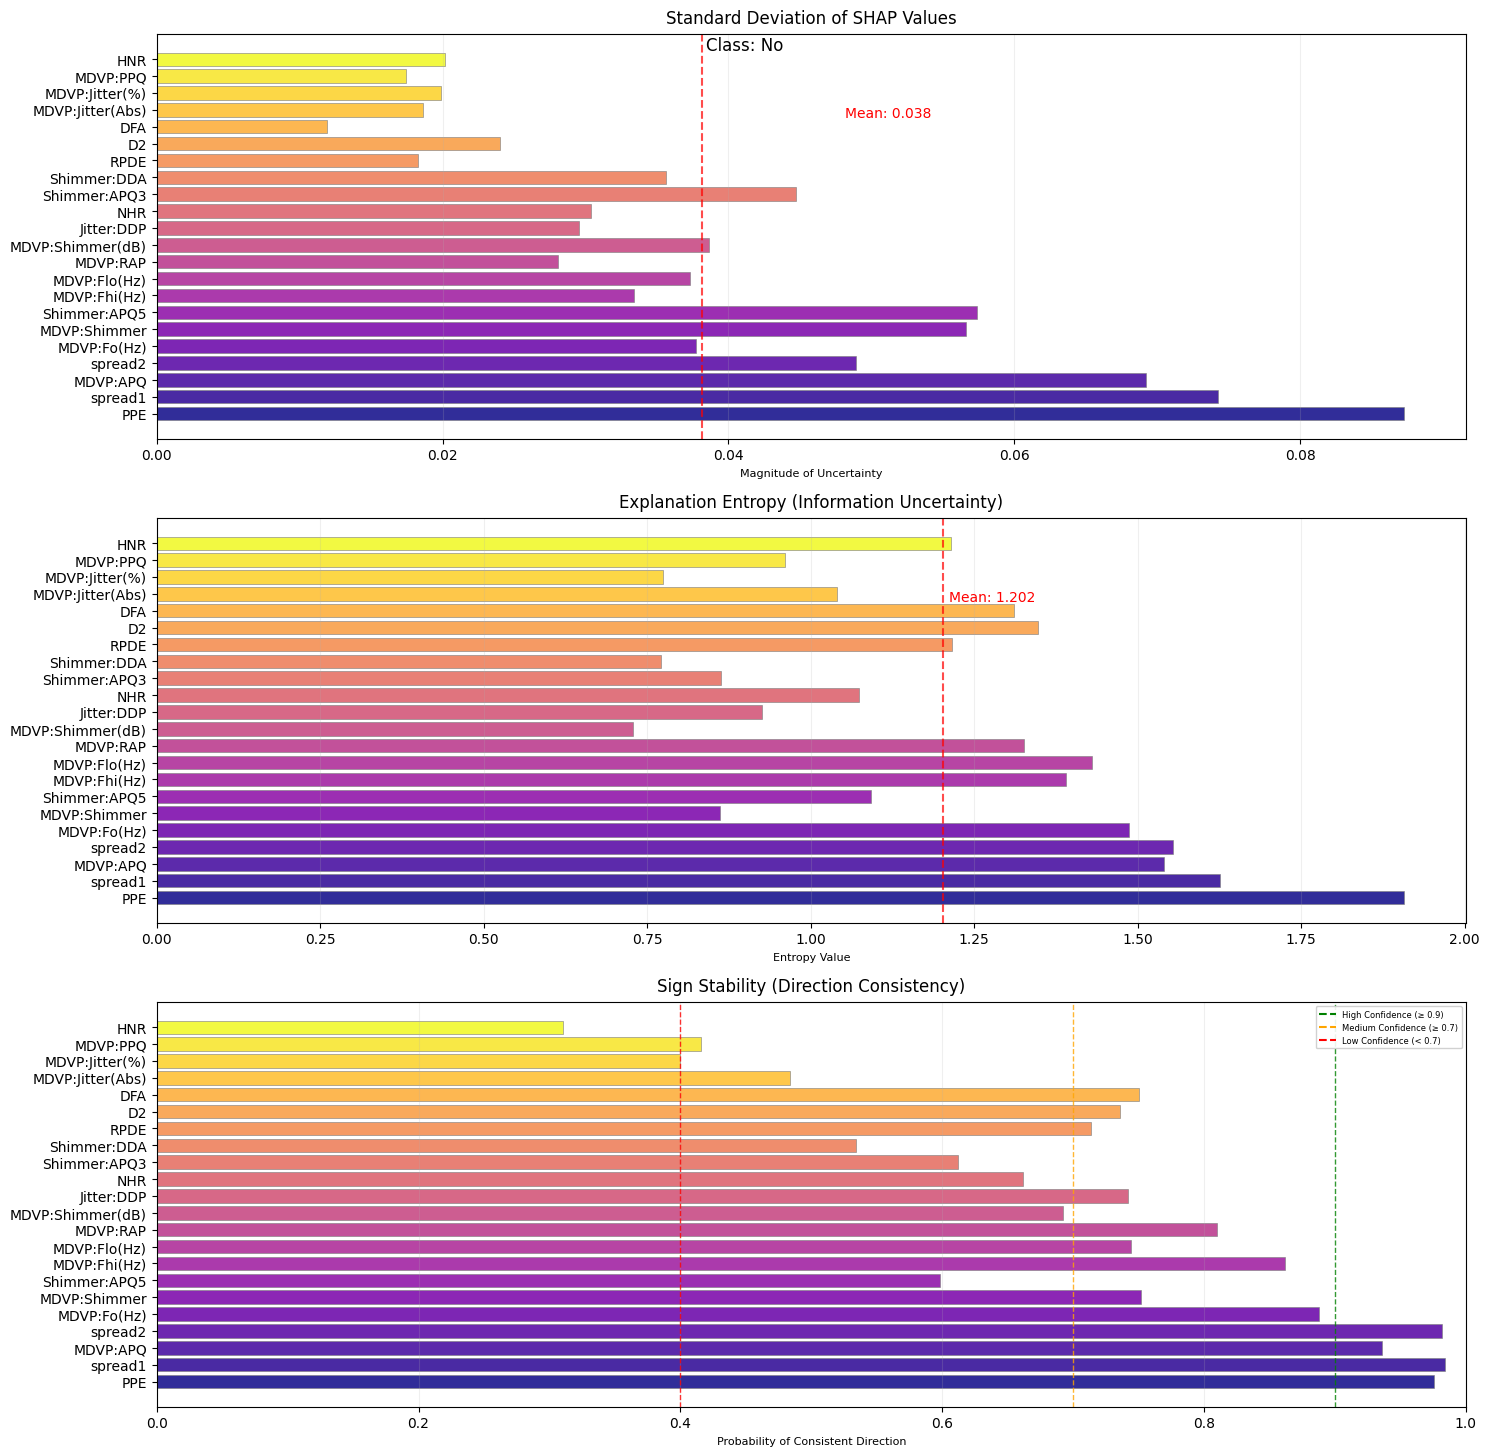


Explaining for class: Yes


Sampling hypothesis space: 100%|██████████| 500/500 [00:03<00:00, 128.33it/s]


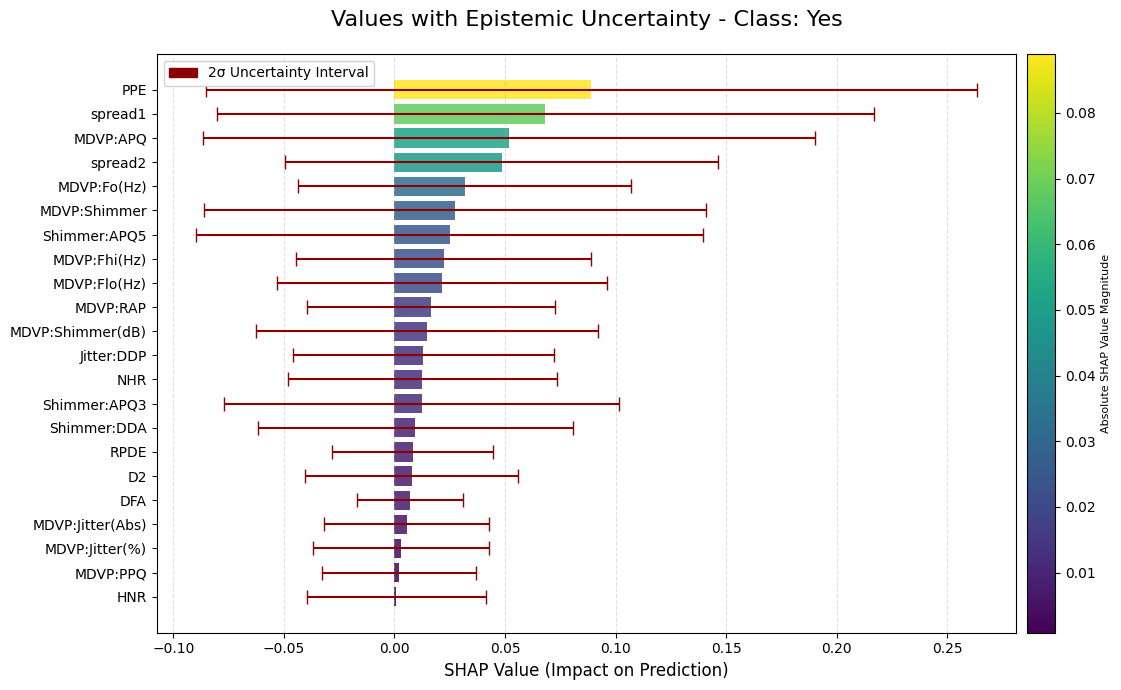

Top 5 indices: [ 0 19 12 18 21]


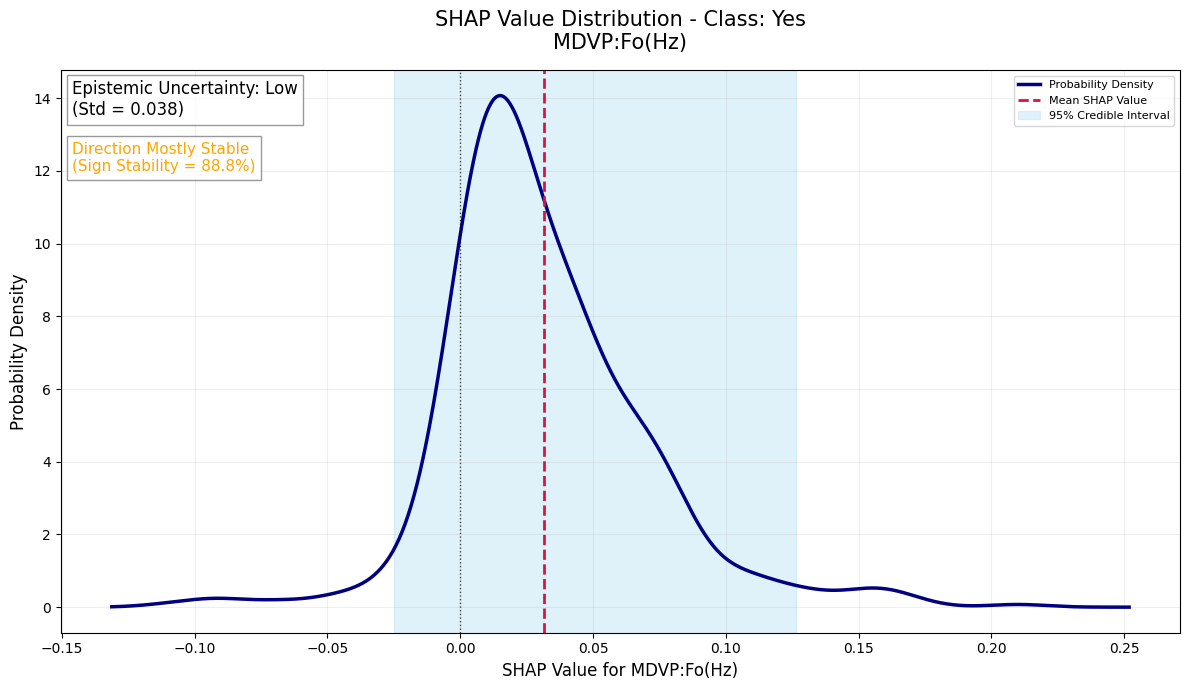

Top 5 indices: [ 0 19 12 18 21]


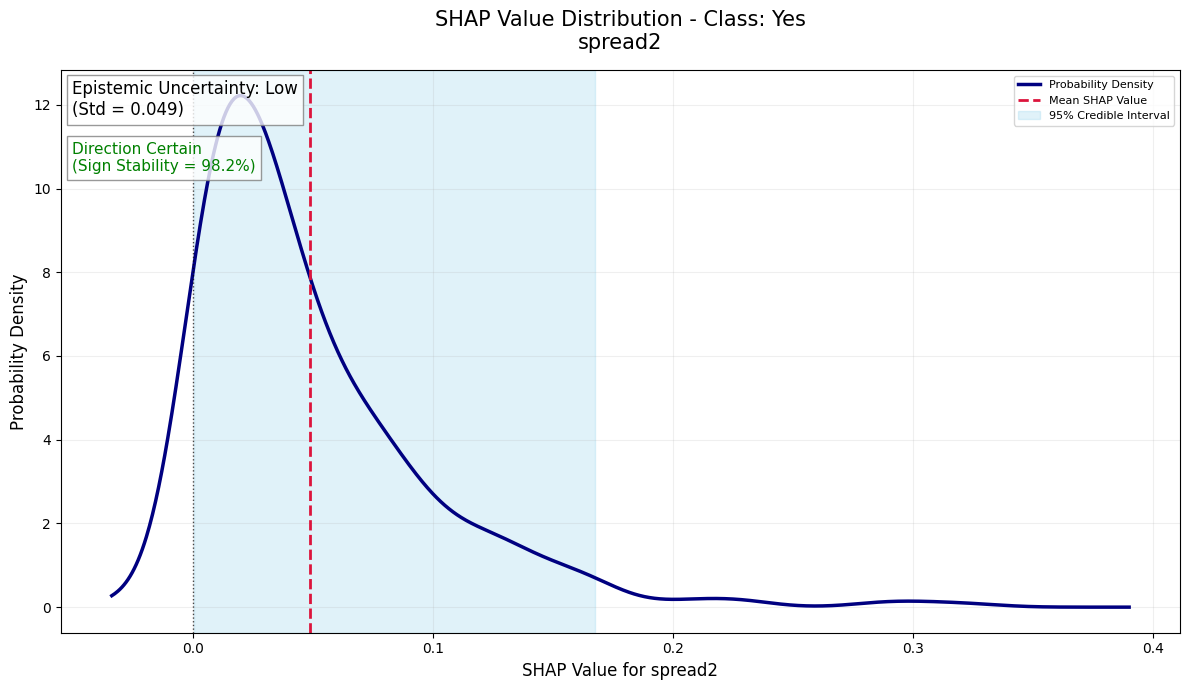

Top 5 indices: [ 0 19 12 18 21]


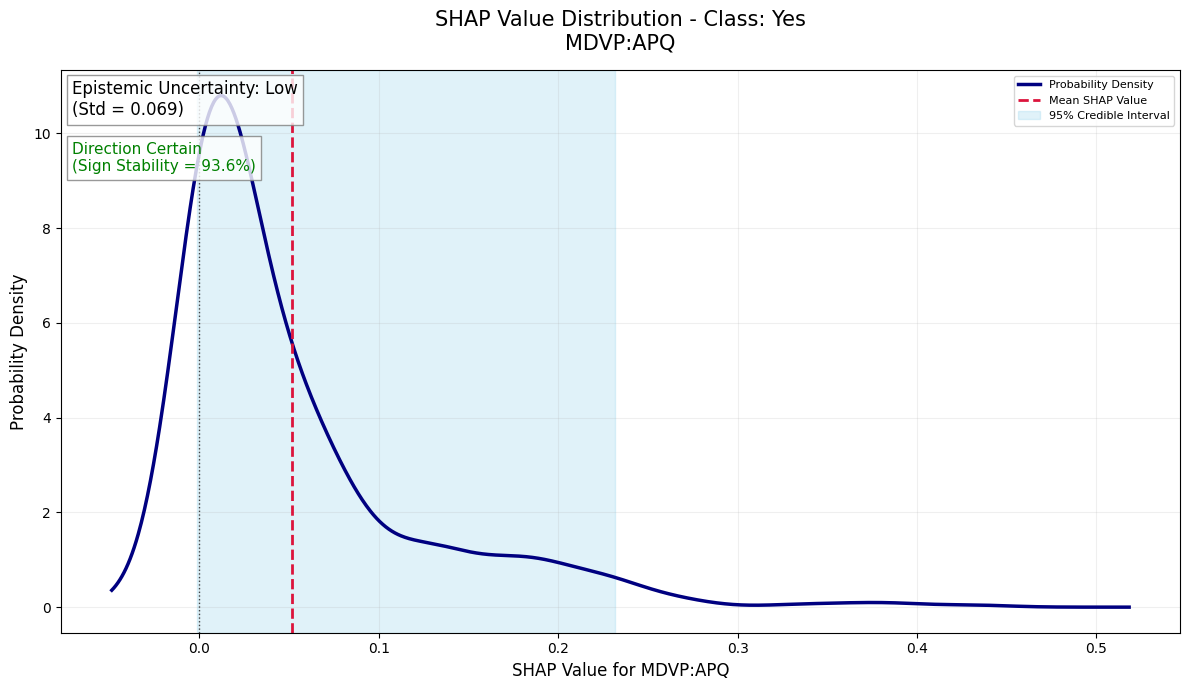

Top 5 indices: [ 0 19 12 18 21]


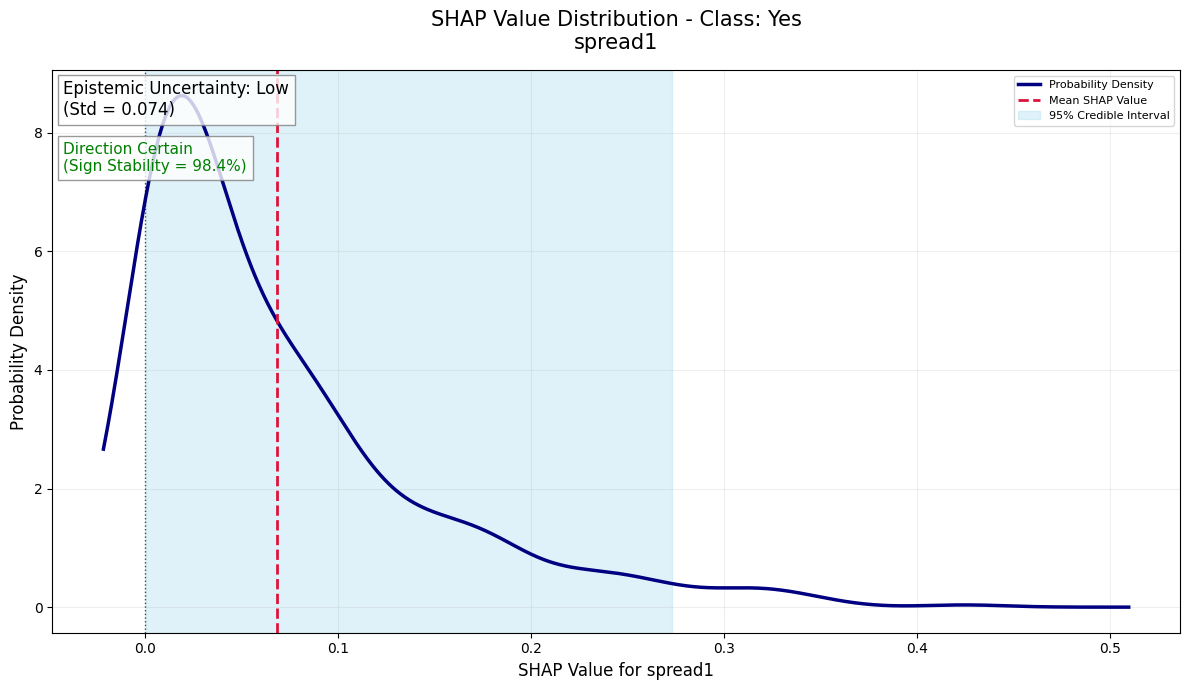

Top 5 indices: [ 0 19 12 18 21]


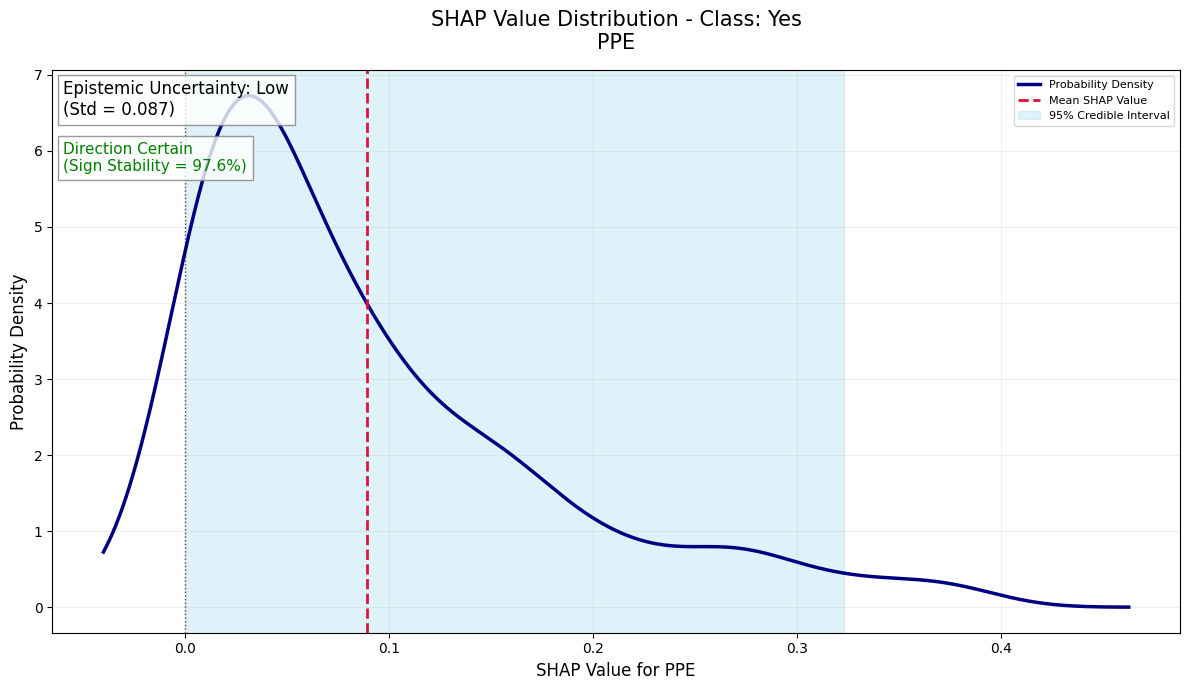

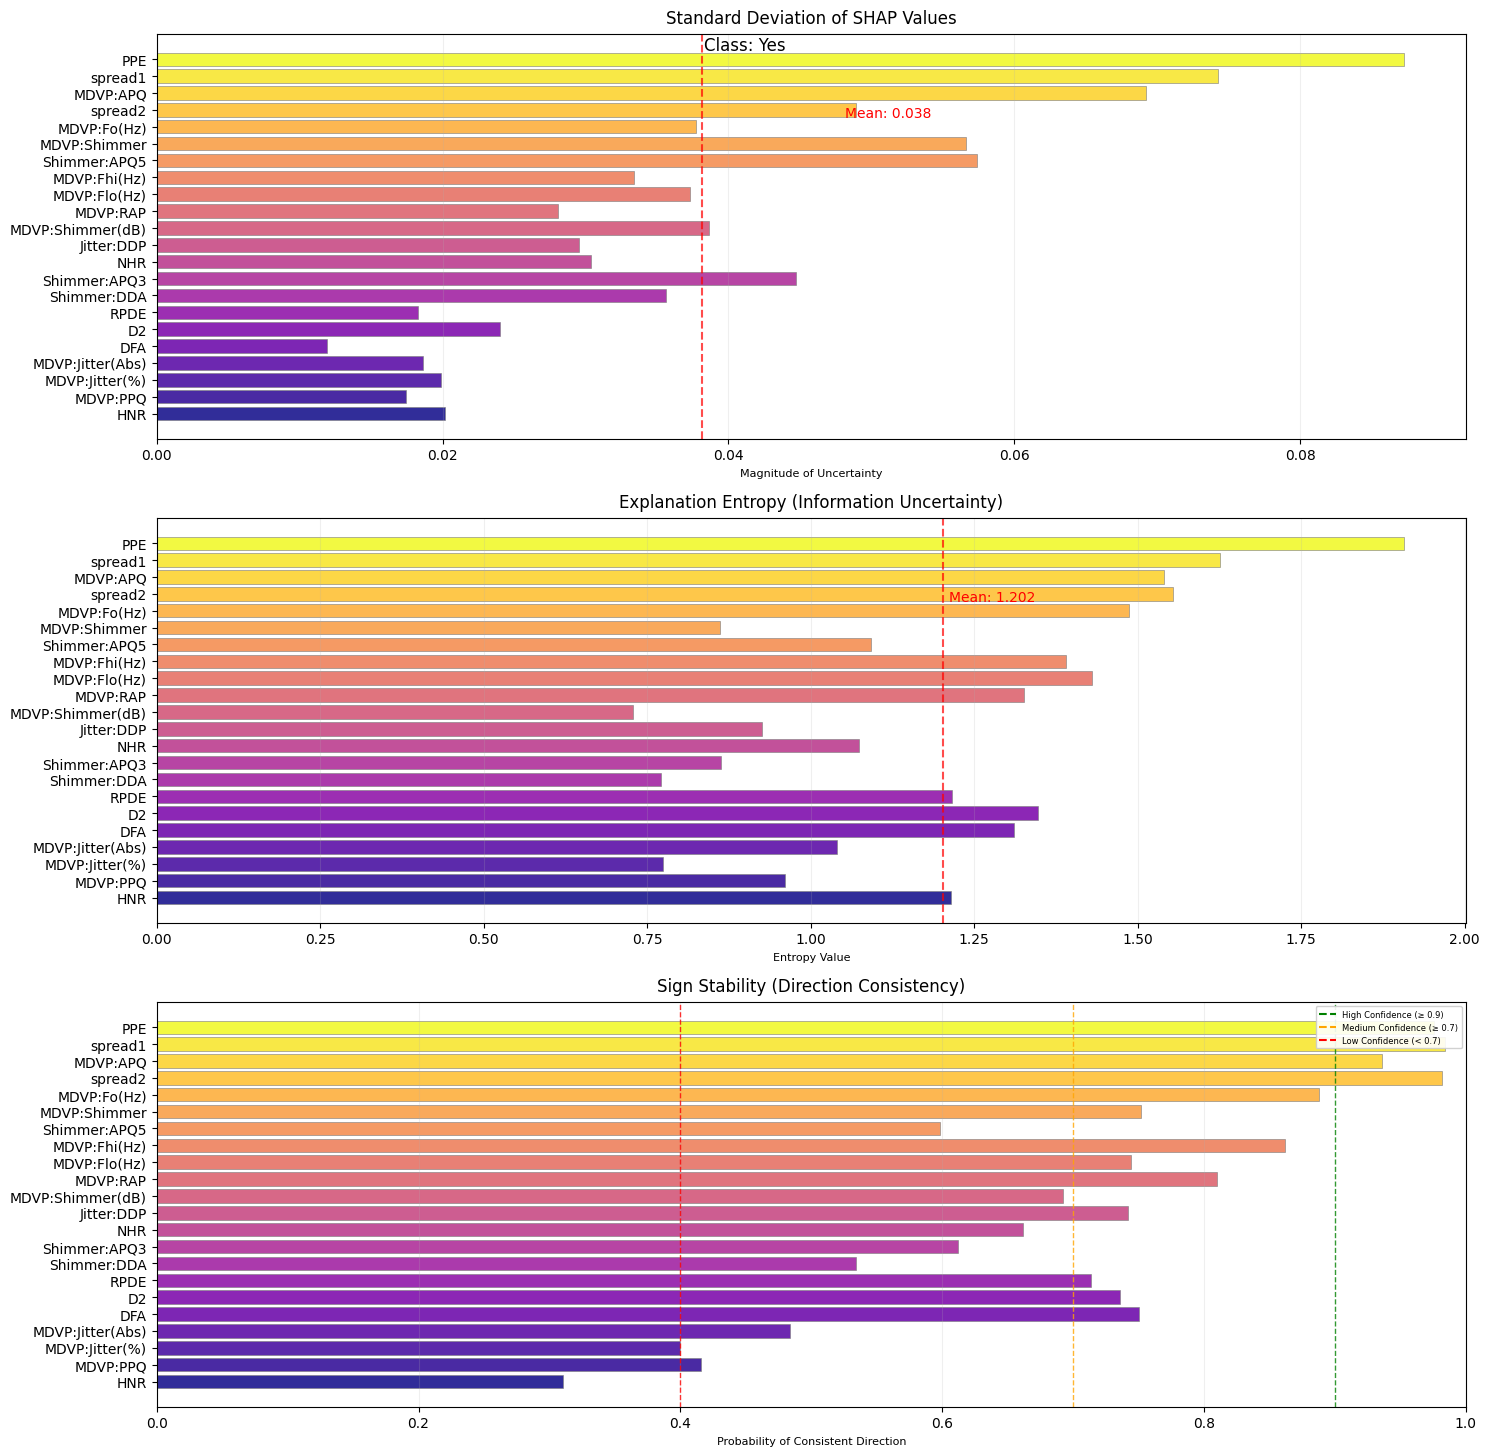

In [17]:

explainer = ExplainerClassification(model, X_train, y_train, beta=5.0, random_state=42)

# Explain first instance for each class
instance = X_test[0:1]

for class_idx, class_name in enumerate(class_names):
    print(f"\nExplaining for class: {class_name}")
    results = explainer.explain(instance, class_idx=class_idx)
       # Plot results
    explainer.plot_uncertainty_bars(
        results, 
        feature_names,
        class_name=class_name
    )
    
    # Plot distribution for most important feature
    # most_important_feature = np.argmax(np.abs(results['mean']))
    # explainer.plot_uncertainty_distribution(
    #     results,
    #     feature_names,
    #     most_important_feature,
    #     class_name=class_name
    # )
    
    top5_indices = np.argsort(np.abs(results["mean"]))[-5:]
    for i in top5_indices:

        print("Top 5 indices:", top5_indices)
        explainer.plot_uncertainty_distribution(
            results,
            feature_names,
            i,
            class_name=class_name
        )
    
    explainer.plot_uncertainty_comparison(
        results,
        feature_names,
        class_name=class_name
    )
